# Tweet Content Permutation or Not

In [ ]:
%matplotlib inline
import sys, json, re, warnings
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from IPython.display import display

SRC = Path("../src")
sys.path.insert(0, str(SRC))

from config import (RESULT_DIRS, CONDITION_LABELS, OUTPUT_DIR,
                    available_result_dirs, EVAL_K, N_RUNS)
from utils import (
    load_results_json, extract_metrics, load_past_visit_metrics_json,
    load_user_metadata, load_tweet_metadata,
    load_past_visit_preds, load_single_run_preds, load_gnn_preds,
    load_mention_rel, split_mention_rel, username_to_user_idx,
    compute_train_indegree,
)

# ── shared palette / constants ───────────────────────────────────────────────
ACTOR_ORDER = ["politician", "journalist", "scientist/academic",
               "ngo", "activist", "organization", "citizen", "inactive"]
ACTOR_COLORS = {
    "politician": "#E91E63", "journalist": "#9C27B0",
    "scientist/academic": "#3F51B5", "ngo": "#00BCD4",
    "activist": "#4CAF50", "organization": "#FF9800",
    "citizen": "#795548", "inactive": "#9E9E9E",
}
GNN_COLOR, PV_COLOR = "#FF5722", "#2196F3"

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
warnings.filterwarnings("ignore", category=FutureWarning)

print("Setup complete.  Output root:", OUTPUT_DIR)

OUT = OUTPUT_DIR / "A_permutation"
OUT.mkdir(parents=True, exist_ok=True)


Setup complete.  Output root: /Users/zhangkexin/Desktop/TP/TP_link_prediction_analysis/analysis_output


In [2]:
METRIC_COLS = [
    ("past_visit_test_link_prediction_map",        "PV MAP@10 test"),
    ("past_visit_val_link_prediction_map",         "PV MAP@10 val"),
    ("past_visit_test_link_prediction_precision",  "PV P@10 test"),
    ("past_visit_test_link_prediction_recall",     "PV R@10 test"),
    ("gnn_best_map_test_map_mean",   "GNN MAP@10 test (mean)"),
    ("gnn_best_map_test_map_std",    "GNN MAP@10 test (std)"),
    ("gnn_best_map_val_map_mean",    "GNN MAP@10 val (mean)"),
    ("gnn_best_map_val_map_std",     "GNN MAP@10 val (std)"),
    ("gnn_best_map_test_precision_mean", "GNN P@10 test (mean)"),
    ("gnn_best_map_test_recall_mean",    "GNN R@10 test (mean)"),
]

avail = available_result_dirs()
rows = []
for key, label in CONDITION_LABELS.items():
    if key not in avail:
        print(f"  [skip] {key} – results.json not found")
        continue
    rdir = avail[key]
    raw  = load_results_json(rdir)
    flat = extract_metrics(raw)
    flat.update(load_past_visit_metrics_json(rdir))
    row  = {"condition": key, "label": label}
    for col_key, col_label in METRIC_COLS:
        row[col_label] = flat.get(col_key, np.nan)
    # Advisor P10: median + IQR from individual runs
    run_maps = [
        run.get("best_map_test_metrics", run.get("test_metrics", {}))
           .get("link_prediction_map", float("nan"))
        for run in raw.get("all_runs", [])
        if run.get("best_map_test_metrics") or run.get("test_metrics")
    ]
    if run_maps:
        arr = np.array(run_maps)
        row["GNN MAP@10 test (median)"] = float(np.nanmedian(arr))
        row["GNN MAP@10 test (IQR)"]    = float(np.nanpercentile(arr, 75)
                                                  - np.nanpercentile(arr, 25))
    else:
        row["GNN MAP@10 test (median)"] = np.nan
        row["GNN MAP@10 test (IQR)"]    = np.nan
    rows.append(row)

df_metrics = pd.DataFrame(rows)

# ── Backfill PV for user_mention_reply conditions ─────────────────────────────
# PV is a structural baseline (historical mention frequency, user→user).
# It does not use tweet content, so Original/Permuted/+Reply all yield the
# same PV score on the same user-to-user test set.  The pipeline's baseline
# block was commented out for the reply conditions, so we propagate the value
# from user_mention_orig.
_PV_COLS = ["PV MAP@10 test", "PV MAP@10 val", "PV P@10 test", "PV R@10 test"]
_REF_COND = "user_mention_orig"
_REPLY_CONDS = ["user_mention_reply_orig", "user_mention_reply_perm"]

ref_row = df_metrics[df_metrics["condition"] == _REF_COND]
if not ref_row.empty:
    for col in _PV_COLS:
        ref_val = ref_row[col].values[0]
        if pd.notna(ref_val):
            for cond in _REPLY_CONDS:
                mask = (df_metrics["condition"] == cond) & df_metrics[col].isna()
                df_metrics.loc[mask, col] = ref_val

df_metrics.to_csv(OUT / "metrics_table.csv", index=False, float_format="%.6f")

show_cols = ["label", "PV MAP@10 test",
             "GNN MAP@10 test (mean)", "GNN MAP@10 test (std)",
             "GNN MAP@10 test (median)", "GNN MAP@10 test (IQR)",
             "GNN MAP@10 val (mean)"]
display(df_metrics[show_cols].style
        .format("{:.4f}", subset=show_cols[1:], na_rep="–")
        .set_caption("MAP@10: all conditions (test & val)"))

,label,PV MAP@10 test,GNN MAP@10 test (mean),GNN MAP@10 test (std),GNN MAP@10 test (median),GNN MAP@10 test (IQR),GNN MAP@10 val (mean)
0,TweetMention / Original,0.1519,0.0376,0.0000,0.0376,0.0000,0.0378
1,TweetMention / Permuted,0.1519,0.0376,0.0000,0.0376,0.0000,0.0378
2,UserMention / Original,0.1137,0.1022,0.0002,0.1023,0.0003,0.0882
3,UserMention / Permuted,0.1137,0.1026,0.0002,0.1026,0.0002,0.0884
4,UserMention+Reply / Original,0.1137,0.1116,0.0005,0.1117,0.0004,0.0971
5,UserMention+Reply / Permuted,0.1137,0.1112,0.0005,0.1112,0.0006,0.0968


In [3]:
metric_cols_noStd = [c for _, c in METRIC_COLS if "std" not in c]
pairs = [
    ("tweet_mention_orig", "tweet_mention_perm",      "TweetMention (content perm)"),
    ("user_mention_orig",  "user_mention_perm",       "UserMention (content perm)"),
    ("user_mention_perm",  "user_mention_reply_perm", "UserMention +Reply data (4L vs 3L)"),
]
es_rows = []
for orig_k, perm_k, task_label in pairs:
    orig_r = df_metrics[df_metrics["condition"] == orig_k]
    perm_r = df_metrics[df_metrics["condition"] == perm_k]
    if orig_r.empty or perm_r.empty:
        print(f"  [skip] {task_label} – one condition not available")
        continue
    orig_r, perm_r = orig_r.iloc[0], perm_r.iloc[0]
    row = {"comparison": task_label}
    for col in metric_cols_noStd:
        o, p = orig_r[col], perm_r[col]
        row[f"Δ {col}"] = (p - o) / o if pd.notna(o) and o != 0 else np.nan
    es_rows.append(row)
df_es = pd.DataFrame(es_rows)
df_es.to_csv(OUT / "effect_sizes.csv", index=False, float_format="%.6f")

delta_cols = [c for c in df_es.columns if c.startswith("Δ")]
display(df_es[["comparison"] + delta_cols].style
        .format("{:+.2%}", subset=delta_cols, na_rep="–")
        .set_caption("Relative effect of permutation on metrics"))
print("\nGNN MAP@10 test deltas:")
for _, r in df_es.iterrows():
    d = r.get("Δ GNN MAP@10 test (mean)", np.nan)
    print(f"  {r['comparison']:<38}  {d:+.4%}" if pd.notna(d) else f"  {r['comparison']} – n/a")


,comparison,Δ PV MAP@10 test,Δ PV MAP@10 val,Δ PV P@10 test,Δ PV R@10 test,Δ GNN MAP@10 test (mean),Δ GNN MAP@10 val (mean),Δ GNN P@10 test (mean),Δ GNN R@10 test (mean)
0,TweetMention (content perm),+0.00%,+0.00%,+0.00%,+0.00%,+0.00%,+0.00%,+0.00%,+0.00%
1,UserMention (content perm),+0.00%,+0.00%,+0.00%,+0.00%,+0.31%,+0.26%,-0.07%,+0.33%
2,UserMention +Reply data (4L vs 3L),+0.00%,+0.00%,+0.00%,+0.00%,+8.43%,+9.54%,+12.75%,+15.27%



GNN MAP@10 test deltas:
  TweetMention (content perm)             +0.0000%
  UserMention (content perm)              +0.3150%
  UserMention +Reply data (4L vs 3L)      +8.4310%


Test-period mentions : 57,367  |  unique src users: 17,718
Emotion coverage     : 100.0%
Degree bin counts    :
deg_bin
cold (0)    27163
1-5          9434
6-20         7212
20+         13558
Name: count, dtype: int64



=== A5: Mention-target overlap across emotion conditions (Jaccard) ===
                     Mean Jaccard  Median Jaccard  N pairs
emotion_pair                                              
joy vs sadness              0.207             0.0       80
optimism vs anger           0.204             0.0      117
optimism vs disgust         0.173             0.0      241
optimism vs fear            0.212             0.0      555

Jaccard ~ 1.0 → same targets regardless of emotion (structure dominates)
Jaccard ~ 0.0 → completely different targets (content drives who gets mentioned)
Saved: /Users/zhangkexin/Desktop/TP/TP_link_prediction_analysis/analysis_output/A_permutation/jaccard_emotion_pairs.png


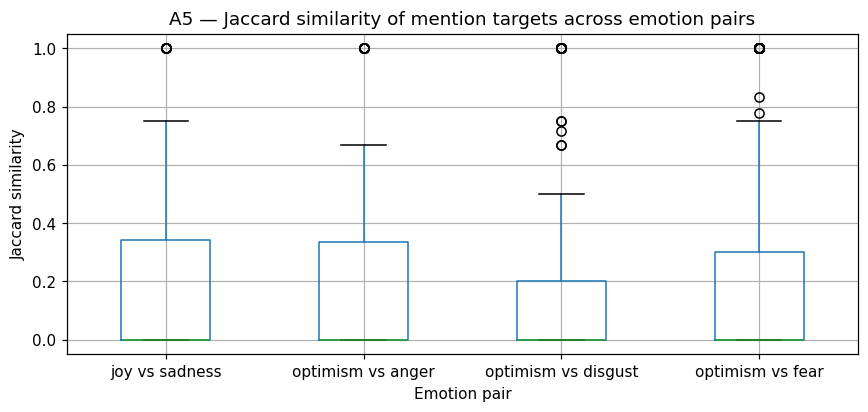

In [ ]:
# Matched-pair natural experiment: does emotion condition change mention targets?
import warnings
warnings.filterwarnings("ignore")

rdir_a5 = RESULT_DIRS["user_mention_orig"]
# tweet_metadata: index name = "tweet_idx" (int64); cols: conversation_id(str tweet ID),
#                 user_idx(src author username), dominant_emotion, ...
tm_a5   = load_tweet_metadata(rdir_a5)
# mention_rel: tweet_idx(str tweet ID), user_idx(dst username), created_at(UTC)
mr_all  = load_mention_rel()

# ── Split by tz-aware timestamps ─────────────────────────────────────────────
TEST_TS  = pd.Timestamp("2019-11-01", tz="UTC")
TRAIN_TS = pd.Timestamp("2019-09-01", tz="UTC")

mr_test  = mr_all[mr_all["created_at"] >= TEST_TS].reset_index(drop=True).copy()
mr_train = mr_all[mr_all["created_at"] <  TRAIN_TS].reset_index(drop=True).copy()

# rename mention_rel.user_idx → dst_user_idx (the mentioned/destination user)
mr_test  = mr_test.rename(columns={"user_idx": "dst_user_idx"})
mr_train = mr_train.rename(columns={"user_idx": "dst_user_idx"})

# ── Build join table: conversation_id → src_user + emotion ───────────────────
# NOTE: tm_a5.index.name == "tweet_idx" → reset_index(drop=True) prevents
#       pandas raising "tweet_idx is both an index level and a column label"
tm_slim = (tm_a5[["conversation_id", "user_idx", "dominant_emotion"]]
           .rename(columns={"conversation_id": "tweet_idx",
                            "user_idx":        "src_user_idx"})
           .reset_index(drop=True))   # ← drop the named "tweet_idx" index

mr_test  = mr_test.merge(tm_slim, on="tweet_idx", how="left")
mr_train = mr_train.merge(tm_slim[["tweet_idx","src_user_idx"]], on="tweet_idx", how="left")

# ── Source-user train out-degree (structural context bin) ────────────────────
src_outdeg = (mr_train.groupby("src_user_idx").size()
              .rename("train_outdeg").reset_index())
mr_test = mr_test.merge(src_outdeg, on="src_user_idx", how="left")
# Use explicit bins (many zeros collapse pd.qcut quantiles)
mr_test["deg_bin"] = pd.cut(
    mr_test["train_outdeg"].fillna(0),
    bins=[-1, 0, 5, 20, float("inf")],
    labels=["cold (0)", "1-5", "6-20", "20+"]
)

print(f"Test-period mentions : {len(mr_test):,}  |  unique src users: {mr_test['src_user_idx'].nunique():,}")
print(f"Emotion coverage     : {mr_test['dominant_emotion'].notna().mean():.1%}")
print(f"Degree bin counts    :\n{mr_test['deg_bin'].value_counts().sort_index()}")

# ── Jaccard similarity of mention targets across emotion pairs ────────────────
EMO_PAIRS = [("optimism","anger"), ("optimism","fear"), ("joy","sadness"), ("optimism","disgust")]
jaccard_rows = []
for (emo_a, emo_b) in EMO_PAIRS:
    for src_user, grp in mr_test.groupby("src_user_idx"):
        targets_a = set(grp[grp["dominant_emotion"] == emo_a]["dst_user_idx"])
        targets_b = set(grp[grp["dominant_emotion"] == emo_b]["dst_user_idx"])
        if not targets_a or not targets_b:
            continue
        union = targets_a | targets_b
        jaccard = len(targets_a & targets_b) / len(union) if union else 1.0
        jaccard_rows.append({"emotion_pair": f"{emo_a} vs {emo_b}",
                              "src": src_user, "jaccard": jaccard,
                              "n_a": len(targets_a), "n_b": len(targets_b)})

if jaccard_rows:
    jdf = pd.DataFrame(jaccard_rows)
    summary = jdf.groupby("emotion_pair")["jaccard"].agg(["mean","median","count"])
    summary.columns = ["Mean Jaccard","Median Jaccard","N pairs"]
    print("\n=== A5: Mention-target overlap across emotion conditions (Jaccard) ===")
    print(summary.round(3))
    print()
    print("Jaccard ~ 1.0 → same targets regardless of emotion (structure dominates)")
    print("Jaccard ~ 0.0 → completely different targets (content drives who gets mentioned)")

    fig, ax = plt.subplots(figsize=(8, 4))
    jdf.boxplot(column="jaccard", by="emotion_pair", ax=ax)
    ax.set_title("A5 — Jaccard similarity of mention targets across emotion pairs")
    ax.set_xlabel("Emotion pair"); ax.set_ylabel("Jaccard similarity")
    plt.suptitle("")
    fig.tight_layout()
    fig.savefig(OUT / "jaccard_emotion_pairs.png", dpi=150, bbox_inches="tight")
    print(f"Saved: {OUT / 'jaccard_emotion_pairs.png'}")
    summary.to_csv(OUT / "jaccard_emotion_pairs.csv")
    plt.show()
else:
    print("No matched emotion pairs found — users rarely tweet with both emotions in test period.")
    print("Consider extending window to include validation period (2019-09 to 2019-11).")


In [ ]:
EMO_PAIRS = [("optimism","anger"), ("optimism","fear"), ("joy","sadness"), ("optimism","disgust")]

# ── Re-derive jdf with deg_bin attached ─────────────────────────────────────
jaccard_rows2 = []
for (emo_a, emo_b) in EMO_PAIRS:
    for src_user, grp in mr_test.groupby("src_user_idx"):
        targets_a = set(grp[grp["dominant_emotion"] == emo_a]["dst_user_idx"])
        targets_b = set(grp[grp["dominant_emotion"] == emo_b]["dst_user_idx"])
        if not targets_a or not targets_b:
            continue
        union = targets_a | targets_b
        j = len(targets_a & targets_b) / len(union)
        db = grp["deg_bin"].iloc[0]
        jaccard_rows2.append({"emotion_pair": f"{emo_a} vs {emo_b}",
                               "src": src_user, "jaccard": j, "deg_bin": db,
                               "n_a": len(targets_a), "n_b": len(targets_b)})

jdf2 = pd.DataFrame(jaccard_rows2)

# ── Stratified summary ───────────────────────────────────────────────────────
bin_order = ["cold (0)", "1-5", "6-20", "20+"]
strat = (jdf2.groupby(["deg_bin", "emotion_pair"])["jaccard"]
             .agg(["mean", "median", "count"])
             .rename(columns={"mean": "Mean J", "median": "Median J", "count": "N"})
             .reindex(pd.MultiIndex.from_product([bin_order,
                      [f"{a} vs {b}" for a,b in EMO_PAIRS]], names=["deg_bin","emotion_pair"])))
print("=== A5b: Jaccard stratified by source-user training out-degree ===")
print(strat.round(3).to_string())
print()
print("Key: if warm users (20+) still show low / lower-than-null Jaccard →")
print("     emotion effect is not purely a sparsity artefact.")

# ── Permutation null: within-user emotion shuffle, matched-pair users only ───
import numpy as np
rng = np.random.default_rng(42)

matched_users = set(jdf2["src"].unique())          # only 80-555 users
mr_matched = mr_test[mr_test["src_user_idx"].isin(matched_users)].copy()

N_PERM = 100
null_rows = []
for _ in range(N_PERM):
    mr_perm = mr_matched.copy()
    mr_perm["dominant_emotion"] = (
        mr_perm.groupby("src_user_idx")["dominant_emotion"]
               .transform(lambda x: x.sample(frac=1,
                          random_state=int(rng.integers(1_000_000))).values)
    )
    for (emo_a, emo_b) in EMO_PAIRS:
        for src_user, grp in mr_perm.groupby("src_user_idx"):
            ta = set(grp[grp["dominant_emotion"] == emo_a]["dst_user_idx"])
            tb = set(grp[grp["dominant_emotion"] == emo_b]["dst_user_idx"])
            if not ta or not tb:
                continue
            u = ta | tb
            null_rows.append({"emotion_pair": f"{emo_a} vs {emo_b}",
                               "jaccard": len(ta & tb) / len(u)})

null_df  = pd.DataFrame(null_rows)
null_sum = null_df.groupby("emotion_pair")["jaccard"].agg(["mean","median"])
null_sum.columns = ["Null Mean J", "Null Median J"]

obs_sum = jdf2.groupby("emotion_pair")["jaccard"].agg(["mean","median"])
obs_sum.columns = ["Obs Mean J", "Obs Median J"]
cmp_emotion = obs_sum.join(null_sum)
cmp_emotion["delta_mean"] = cmp_emotion["Obs Mean J"] - cmp_emotion["Null Mean J"]
print("\n=== A5b: Observed vs. permutation-null Jaccard (within-user shuffle) ===")
print(cmp_emotion.round(3).to_string())
print()
print("Negative delta_mean → emotion reduces overlap beyond what sparsity predicts")
print("Near-zero delta     → low Jaccard is explained by sparsity alone")

strat.to_csv(OUT / "jaccard_stratified.csv")


=== A5b: Jaccard stratified by source-user training out-degree ===
                              Mean J  Median J    N
deg_bin  emotion_pair                              
cold (0) optimism vs anger     0.288     0.250   33
         optimism vs fear      0.274     0.125  134
         joy vs sadness        0.330     0.083   22
         optimism vs disgust   0.185     0.000   54
1-5      optimism vs anger     0.202     0.000   19
         optimism vs fear      0.194     0.000  104
         joy vs sadness        0.139     0.000   12
         optimism vs disgust   0.147     0.000   43
6-20     optimism vs anger     0.093     0.000   17
         optimism vs fear      0.164     0.000  116
         joy vs sadness        0.199     0.000   12
         optimism vs disgust   0.151     0.000   34
20+      optimism vs anger     0.187     0.000   48
         optimism vs fear      0.208     0.081  201
         joy vs sadness        0.155     0.000   34
         optimism vs disgust   0.185     0.000  1


=== A5b: Observed vs. permutation-null Jaccard (within-user shuffle) ===
                     Obs Mean J  Obs Median J  Null Mean J  Null Median J  delta_mean
emotion_pair                                                                         
joy vs sadness            0.207           0.0        0.204            0.0       0.003
optimism vs anger         0.204           0.0        0.190            0.0       0.014
optimism vs disgust       0.173           0.0        0.167            0.0       0.006
optimism vs fear          0.212           0.0        0.196            0.0       0.016

Negative delta_mean → emotion reduces overlap beyond what sparsity predicts
Near-zero delta     → low Jaccard is explained by sparsity alone


Rows in mr_a5c      : 57,367
label_type  coverage: 100.0%
label_cons  coverage: 100.0%

label_type counts:
 label_type
Posters/Event invitations    29919
Photo                         7579
Text                          7059
Illustration                  6402
Data Visualization            3057
Meme                          1768
Other                          956
Collage                        627
Name: count, dtype: int64

label_consequences counts:
 label_consequences
Covid & general health          35853
Other extreme weather events     5204
Wildfires                        3694
Rising temperature               2267
Melting Ice                      1953
Economic consequences            1758
Biodiversity loss                1687
Drought                          1203
Other consequences               1073
Sea level rise                    974
Floods                            926
Human rights                      775
Name: count, dtype: int64
=== Running label_type analysis ===



=== label_type: Observed vs. permutation-null Jaccard ===
                                   Obs Mean J  Obs Median J  N users  Null Mean J  Null Median J  delta_mean
pair                                                                                                        
Photo vs Illustration                   0.238           0.0      445        0.201            0.0       0.037
Text vs Meme                            0.245           0.0       82        0.201            0.0       0.044
Text vs Photo                           0.208           0.0      357        0.197            0.0       0.011
Text vs Posters/Event invitations       0.228           0.0      727        0.219            0.0       0.009

=== Running label_consequences analysis ===



=== label_consequences: Observed vs. permutation-null Jaccard ===
                                              Obs Mean J  Obs Median J  N users  Null Mean J  Null Median J  delta_mean
pair                                                                                                                   
Covid & general health vs Melting Ice              0.200           0.0      350        0.187            0.0       0.013
Covid & general health vs Rising temperature       0.205           0.0      352        0.187            0.0       0.018
Covid & general health vs Wildfires                0.219           0.0      523        0.214            0.0       0.006
Rising temperature vs Biodiversity loss            0.181           0.0       82        0.163            0.0       0.018
Wildfires vs Floods                                0.117           0.0       55        0.126            0.0      -0.009

Saved: /Users/zhangkexin/Desktop/TP/TP_link_prediction_analysis/analysis_output/A_permutatio

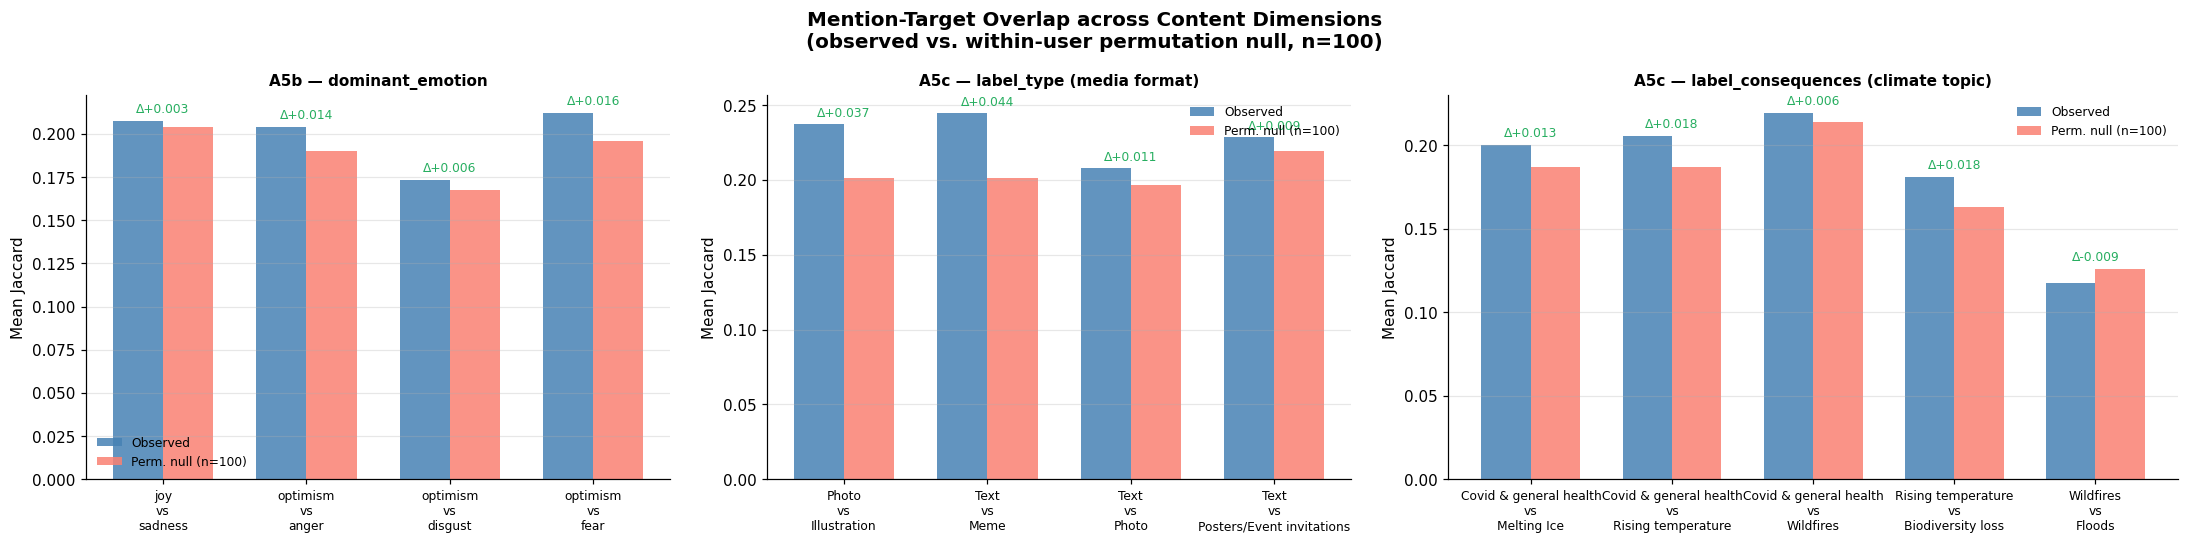

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# ── Load label columns and join onto mr_test built in A5 ────────────────────
rdir_a5c = RESULT_DIRS['user_mention_orig']
tm_labels = pd.read_parquet(
    rdir_a5c / 'tweet_metadata.parquet',
    columns=['conversation_id', 'label_type', 'label_consequences']
)

mr_a5c = mr_test.merge(tm_labels, left_on='tweet_idx', right_on='conversation_id', how='left')

print(f'Rows in mr_a5c      : {len(mr_a5c):,}')
print(f'label_type  coverage: {mr_a5c["label_type"].notna().mean():.1%}')
print(f'label_cons  coverage: {mr_a5c["label_consequences"].notna().mean():.1%}')
print()
print('label_type counts:\n', mr_a5c['label_type'].value_counts())
print()
print('label_consequences counts:\n', mr_a5c['label_consequences'].value_counts())

# ── Helper: observed Jaccard + permutation null for any label column ──────────
def jaccard_analysis(mr, label_col, pairs, n_perm=100, rng_seed=42):
    rng = np.random.default_rng(rng_seed)
    obs_rows = []
    for (la, lb) in pairs:
        for src, grp in mr.groupby('src_user_idx'):
            ta = set(grp[grp[label_col] == la]['dst_user_idx'])
            tb = set(grp[grp[label_col] == lb]['dst_user_idx'])
            if not ta or not tb:
                continue
            u = ta | tb
            obs_rows.append({
                'pair': f'{la} vs {lb}',
                'src': src,
                'jaccard': len(ta & tb) / len(u),
                'n_a': len(ta), 'n_b': len(tb),
                'deg_bin': grp['deg_bin'].iloc[0]
            })
    jdf = pd.DataFrame(obs_rows)
    if jdf.empty:
        print(f'  No matched pairs found for {label_col}.')
        return jdf, pd.DataFrame()

    matched_users = set(jdf['src'].unique())
    mr_matched = mr[mr['src_user_idx'].isin(matched_users)].copy()
    null_rows = []
    for _ in range(n_perm):
        mr_perm = mr_matched.copy()
        mr_perm[label_col] = (
            mr_perm.groupby('src_user_idx')[label_col]
                   .transform(lambda x: x.sample(
                       frac=1, random_state=int(rng.integers(1_000_000))).values)
        )
        for (la, lb) in pairs:
            for src, grp in mr_perm.groupby('src_user_idx'):
                ta = set(grp[grp[label_col] == la]['dst_user_idx'])
                tb = set(grp[grp[label_col] == lb]['dst_user_idx'])
                if not ta or not tb:
                    continue
                u = ta | tb
                null_rows.append({'pair': f'{la} vs {lb}',
                                  'jaccard': len(ta & tb) / len(u)})
    null_df = pd.DataFrame(null_rows)
    null_sum = null_df.groupby('pair')['jaccard'].agg(['mean', 'median'])
    null_sum.columns = ['Null Mean J', 'Null Median J']
    obs_sum = jdf.groupby('pair')['jaccard'].agg(['mean', 'median', 'count'])
    obs_sum.columns = ['Obs Mean J', 'Obs Median J', 'N users']
    comparison = obs_sum.join(null_sum)
    comparison['delta_mean'] = comparison['Obs Mean J'] - comparison['Null Mean J']
    return jdf, comparison

# ── Define pairs ──────────────────────────────────────────────────────────────
TYPE_PAIRS = [
    ('Photo',  'Illustration'),
    ('Text',   'Meme'),
    ('Text',   'Photo'),
    ('Text',   'Posters/Event invitations'),
]

CONS_PAIRS = [
    ('Covid & general health', 'Melting Ice'),
    ('Covid & general health', 'Rising temperature'),
    ('Covid & general health', 'Wildfires'),
    ('Rising temperature',     'Biodiversity loss'),
    ('Wildfires',              'Floods'),
]

# ── Run analyses ──────────────────────────────────────────────────────────────
print('=== Running label_type analysis ===')
jdf_type, cmp_type = jaccard_analysis(mr_a5c, 'label_type', TYPE_PAIRS)
print('\n=== label_type: Observed vs. permutation-null Jaccard ===')
print(cmp_type.round(3).to_string())

print('\n=== Running label_consequences analysis ===')
jdf_cons, cmp_cons = jaccard_analysis(mr_a5c, 'label_consequences', CONS_PAIRS)
print('\n=== label_consequences: Observed vs. permutation-null Jaccard ===')
print(cmp_cons.round(3).to_string())

# ── Combined 3-panel figure: A5b emotion | A5c label_type | A5c label_consequences ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5),
                         gridspec_kw={'width_ratios': [4, 4, 5]})
fig.suptitle('Mention-Target Overlap across Content Dimensions\n'
             '(observed vs. within-user permutation null, n=100)',
             fontsize=13, fontweight='bold')

panel_data = [
    (axes[0], cmp_emotion, 'A5b — dominant_emotion'),
    (axes[1], cmp_type,    'A5c — label_type (media format)'),
    (axes[2], cmp_cons,    'A5c — label_consequences (climate topic)'),
]

for ax, cmp, title in panel_data:
    if cmp is None or cmp.empty:
        ax.set_title(f'{title}\n(no data)', fontsize=10)
        ax.axis('off')
        continue

    ep = cmp.index.tolist()
    x  = np.arange(len(ep))
    w  = 0.35

    ax.bar(x - w/2, cmp['Obs Mean J'],  width=w, label='Observed',
           color='steelblue', alpha=0.85)
    ax.bar(x + w/2, cmp['Null Mean J'], width=w, label='Perm. null (n=100)',
           color='salmon', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels([e.replace(' vs ', '\nvs\n') for e in ep],
                       fontsize=8, ha='center')
    ax.set_ylabel('Mean Jaccard')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

    # Annotate delta on top of each pair
    for xi, row in zip(x, cmp.itertuples()):
        d = row.delta_mean
        color = '#c0392b' if d < -0.01 else '#27ae60'
        top_y = max(row._fields and getattr(row, 'Obs Mean J', 0),
                    getattr(row, 'Null Mean J', 0))
        # Use column positions directly
        obs_j  = cmp.loc[row.Index, 'Obs Mean J']
        null_j = cmp.loc[row.Index, 'Null Mean J']
        ax.text(xi, max(obs_j, null_j) + 0.005,
                f'\u0394{d:+.3f}', ha='center', fontsize=8, color=color)

fig.tight_layout()
fig.savefig(OUT / 'jaccard_combined_A5.png', dpi=150, bbox_inches='tight')
print(f'\nSaved: {OUT / "jaccard_combined_A5.png"}')

if not cmp_type.empty:
    cmp_type.to_csv(OUT / 'jaccard_label_type.csv')
if not cmp_cons.empty:
    cmp_cons.to_csv(OUT / 'jaccard_label_consequences.csv')

plt.show()


Full 2019 mentions : 329,920
Date range         : 2019-01-01 → 2019-12-31


Rows with src_user : 329,920
Unique src users   : 72,067
Emotion coverage   : 100.0%
label_type cov     : 100.0%
label_cons  cov    : 100.0%

=== Running dominant_emotion (full 2019) ===


                     Obs Mean J  Obs Median J  N users  Null Mean J  Null Median J  delta_mean
pair                                                                                          
joy vs sadness            0.132           0.0      858        0.129            0.0       0.004
optimism vs anger         0.158           0.0     1123        0.149            0.0       0.009
optimism vs disgust       0.136           0.0     1773        0.137            0.0      -0.001
optimism vs fear          0.151           0.0     3631        0.148            0.0       0.002

=== Running label_type (full 2019) ===


                                   Obs Mean J  Obs Median J  N users  Null Mean J  Null Median J  delta_mean
pair                                                                                                        
Photo vs Illustration                   0.183           0.0     3135        0.171            0.0       0.012
Text vs Meme                            0.163           0.0      659        0.149            0.0       0.014
Text vs Photo                           0.155           0.0     3032        0.151            0.0       0.004
Text vs Posters/Event invitations       0.170           0.0     5521        0.160            0.0       0.010

=== Running label_consequences (full 2019) ===


                                              Obs Mean J  Obs Median J  N users  Null Mean J  Null Median J  delta_mean
pair                                                                                                                   
Covid & general health vs Melting Ice              0.162           0.0     2393        0.155            0.0       0.007
Covid & general health vs Rising temperature       0.154           0.0     2437        0.147            0.0       0.007
Covid & general health vs Wildfires                0.159           0.0     3556        0.160            0.0      -0.001
Rising temperature vs Biodiversity loss            0.161           0.0      632        0.142            0.0       0.019
Wildfires vs Floods                                0.151           0.0      497        0.143            0.0       0.008

Saved: /Users/zhangkexin/Desktop/TP/TP_link_prediction_analysis/analysis_output/A_permutation/jaccard_combined_full2019.png


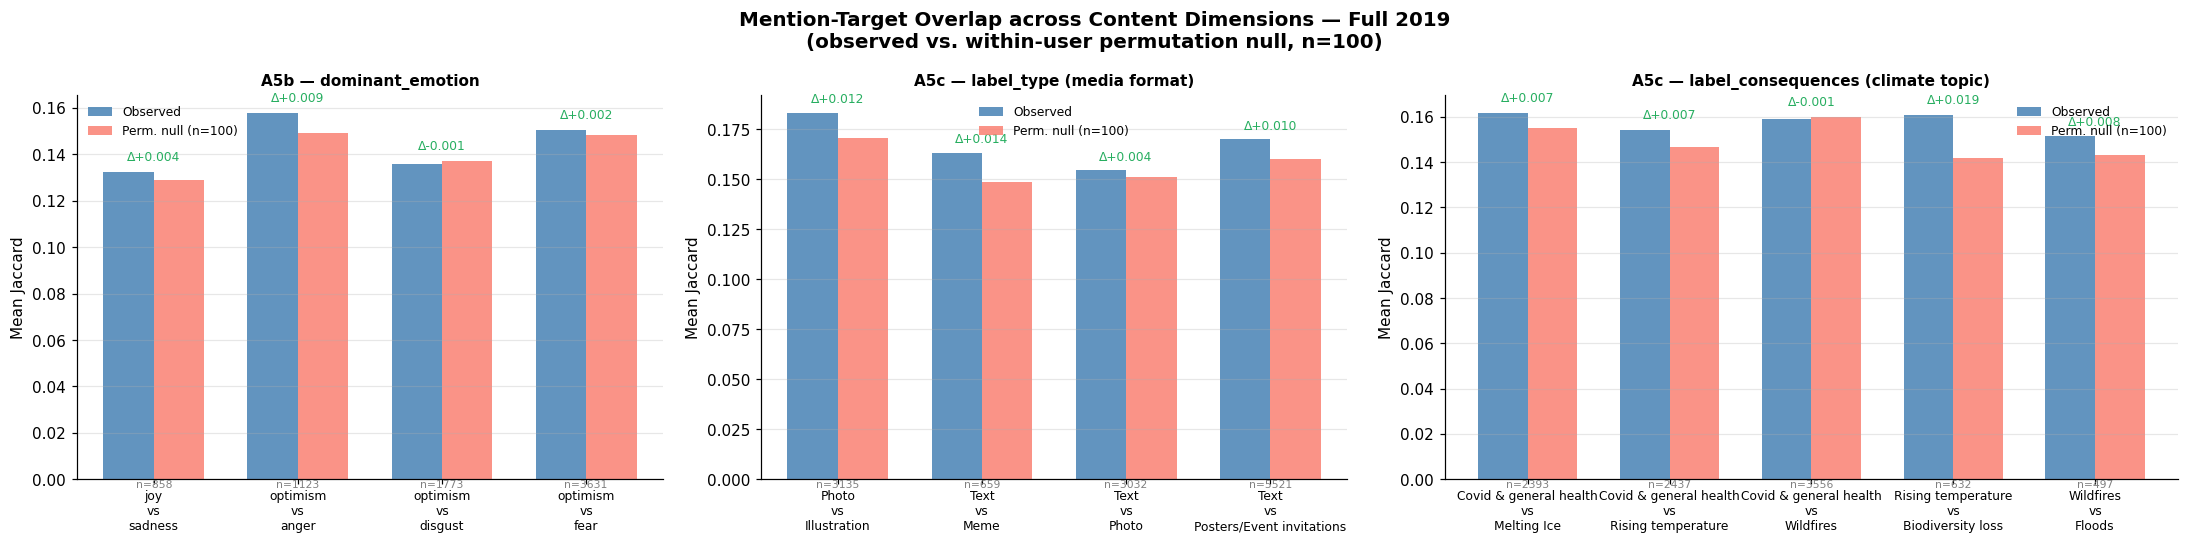

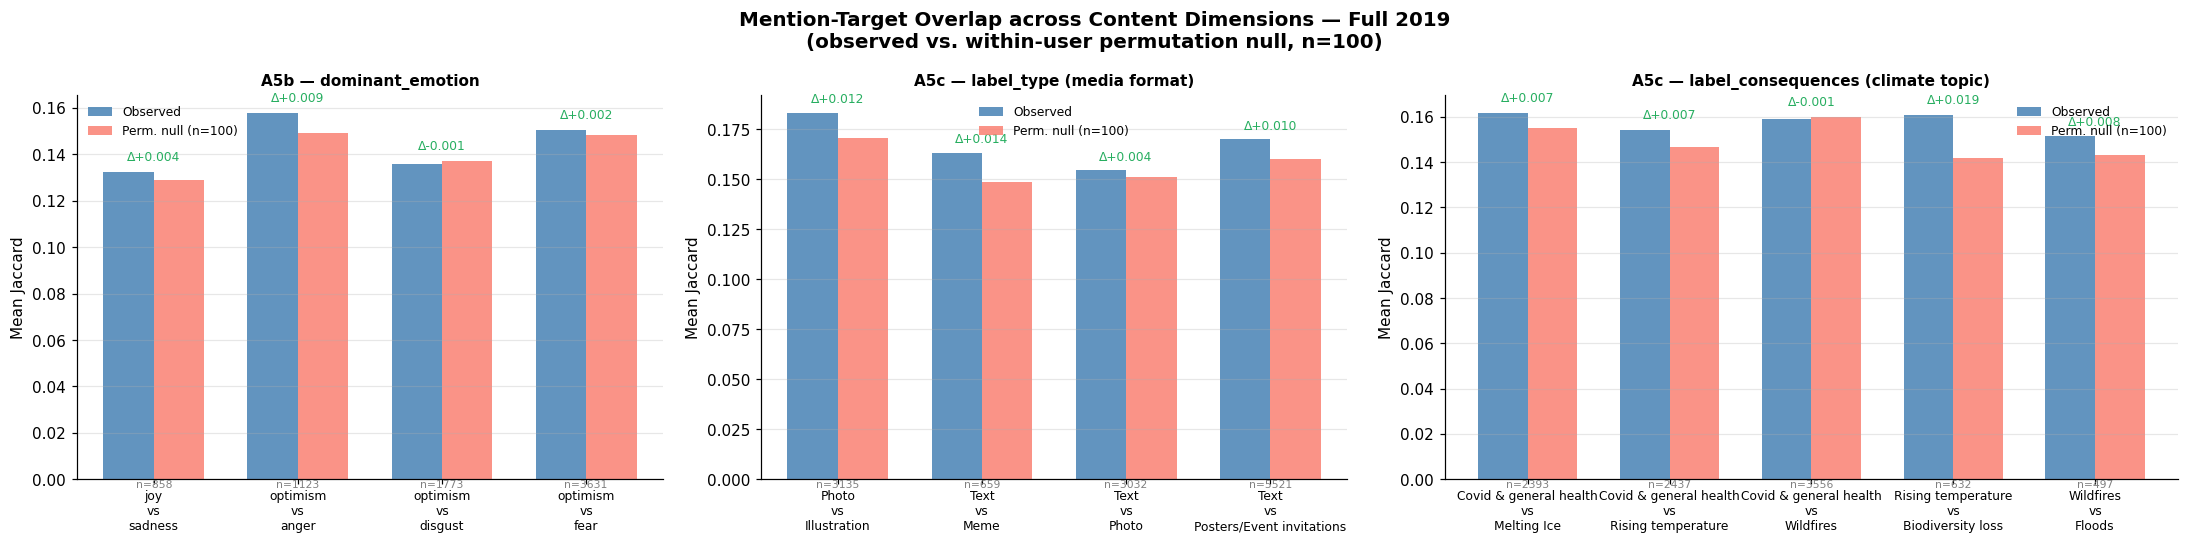

In [ ]:
# Full-2019 scope
import warnings
warnings.filterwarnings('ignore')

# ── Load full mention_rel (all of 2019) via existing utility ─────────────────
mr_full_raw = load_mention_rel().rename(columns={"user_idx": "dst_user_idx"}).copy()

print(f"Full 2019 mentions : {len(mr_full_raw):,}")
print(f"Date range         : {mr_full_raw['created_at'].min().date()} → {mr_full_raw['created_at'].max().date()}")

# ── Load metadata (all three label columns) ───────────────────────────────────
tm_full = pd.read_parquet(
    rdir_a5 / "tweet_metadata.parquet",
    columns=["conversation_id", "user_idx", "dominant_emotion", "label_type", "label_consequences"]
).rename(columns={"conversation_id": "tweet_idx", "user_idx": "src_user_idx"})

# ── Build structural context: train out-degree (before Sep 2019) ──────────────
TRAIN_TS = pd.Timestamp("2019-09-01", tz="UTC")
mr_train_full = mr_full_raw[mr_full_raw["created_at"] < TRAIN_TS].copy()
mr_train_full = mr_train_full.merge(
    tm_full[["tweet_idx", "src_user_idx"]], on="tweet_idx", how="left"
)
src_outdeg_full = (mr_train_full.groupby("src_user_idx").size()
                   .rename("train_outdeg").reset_index())

# ── Merge everything into mr_2019 ─────────────────────────────────────────────
mr_2019 = (mr_full_raw
           .merge(tm_full, on="tweet_idx", how="left")
           .merge(src_outdeg_full, on="src_user_idx", how="left"))

mr_2019["deg_bin"] = pd.cut(
    mr_2019["train_outdeg"].fillna(0),
    bins=[-1, 0, 5, 20, float("inf")],
    labels=["cold (0)", "1-5", "6-20", "20+"]
)

print(f"Rows with src_user : {mr_2019['src_user_idx'].notna().sum():,}")
print(f"Unique src users   : {mr_2019['src_user_idx'].nunique():,}")
print(f"Emotion coverage   : {mr_2019['dominant_emotion'].notna().mean():.1%}")
print(f"label_type cov     : {mr_2019['label_type'].notna().mean():.1%}")
print(f"label_cons  cov    : {mr_2019['label_consequences'].notna().mean():.1%}")

# ── Run all three analyses ────────────────────────────────────────────────────
EMO_PAIRS_FULL = [
    ("optimism", "anger"),
    ("optimism", "fear"),
    ("joy",      "sadness"),
    ("optimism", "disgust"),
]
TYPE_PAIRS_FULL = [
    ("Photo",  "Illustration"),
    ("Text",   "Meme"),
    ("Text",   "Photo"),
    ("Text",   "Posters/Event invitations"),
]
CONS_PAIRS_FULL = [
    ("Covid & general health", "Melting Ice"),
    ("Covid & general health", "Rising temperature"),
    ("Covid & general health", "Wildfires"),
    ("Rising temperature",     "Biodiversity loss"),
    ("Wildfires",              "Floods"),
]

print("\n=== Running dominant_emotion (full 2019) ===")
_, cmp_emo_full  = jaccard_analysis(mr_2019, "dominant_emotion",   EMO_PAIRS_FULL)
print(cmp_emo_full.round(3).to_string())

print("\n=== Running label_type (full 2019) ===")
_, cmp_type_full = jaccard_analysis(mr_2019, "label_type",         TYPE_PAIRS_FULL)
print(cmp_type_full.round(3).to_string())

print("\n=== Running label_consequences (full 2019) ===")
_, cmp_cons_full = jaccard_analysis(mr_2019, "label_consequences",  CONS_PAIRS_FULL)
print(cmp_cons_full.round(3).to_string())

# ── Combined 3-panel figure (full-2019 scope) ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5),
                         gridspec_kw={"width_ratios": [4, 4, 5]})
fig.suptitle("Mention-Target Overlap across Content Dimensions — Full 2019\n"
             "(observed vs. within-user permutation null, n=100)",
             fontsize=13, fontweight="bold")

panel_data = [
    (axes[0], cmp_emo_full,  "A5b — dominant_emotion"),
    (axes[1], cmp_type_full, "A5c — label_type (media format)"),
    (axes[2], cmp_cons_full, "A5c — label_consequences (climate topic)"),
]

for ax, cmp, title in panel_data:
    if cmp is None or cmp.empty:
        ax.set_title(f"{title}\n(no data)"); ax.axis("off"); continue

    ep = cmp.index.tolist()
    x, w = np.arange(len(ep)), 0.35

    ax.bar(x - w/2, cmp["Obs Mean J"],  width=w, label="Observed",
           color="steelblue", alpha=0.85)
    ax.bar(x + w/2, cmp["Null Mean J"], width=w, label="Perm. null (n=100)",
           color="salmon", alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels([e.replace(" vs ", "\nvs\n") for e in ep],
                       fontsize=8, ha="center")
    ax.set_ylabel("Mean Jaccard")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

    for xi, row in zip(x, cmp.itertuples()):
        d = row.delta_mean
        color = "#c0392b" if d < -0.01 else "#27ae60"
        obs_j  = cmp.loc[row.Index, "Obs Mean J"]
        null_j = cmp.loc[row.Index, "Null Mean J"]
        n      = cmp.loc[row.Index, "N users"] if "N users" in cmp.columns else None
        ax.text(xi, max(obs_j, null_j) + 0.005,
                f"\u0394{d:+.3f}", ha="center", fontsize=8, color=color)
        if n is not None:
            ax.text(xi, -0.022, f"n={int(n)}", ha="center", fontsize=7,
                    color="gray", transform=ax.get_xaxis_transform())

fig.tight_layout()
fig.savefig(OUT / "jaccard_combined_full2019.png", dpi=150, bbox_inches="tight")
print(f"\nSaved: {OUT / 'jaccard_combined_full2019.png'}")

if not cmp_emo_full.empty:
    cmp_emo_full.to_csv(OUT / "jaccard_full2019_emotion.csv")
if not cmp_type_full.empty:
    cmp_type_full.to_csv(OUT / "jaccard_full2019_label_type.csv")
if not cmp_cons_full.empty:
    cmp_cons_full.to_csv(OUT / "jaccard_full2019_label_consequences.csv")

plt.show()
